<a href="https://colab.research.google.com/github/345bc/th-deep-learning/blob/main/BTTuan03_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CONVOLUTIONAL NEURAL NETWORK




In [3]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

Load dữ liệu

In [4]:
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

Xử lý dữ liệu

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

Chuyển giá trị nhãn thành one-hot encoding

In [6]:
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

Xây dựng mô hình CNN

In [7]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Huấn luyện mô hình

In [8]:

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 29ms/step - accuracy: 0.9570 - loss: 0.1430 - val_accuracy: 0.9804 - val_loss: 0.0624
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9848 - loss: 0.0481 - val_accuracy: 0.9861 - val_loss: 0.0417
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9897 - loss: 0.0326 - val_accuracy: 0.9891 - val_loss: 0.0353
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9920 - loss: 0.0243 - val_accuracy: 0.9912 - val_loss: 0.0288
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 29ms/step - accuracy: 0.9945 - loss: 0.0171 - val_accuracy: 0.9877 - val_loss: 0.0423


đánh giá

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9877 - loss: 0.0423
Accuracy: 0.9876999855041504


dự đoán


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
7


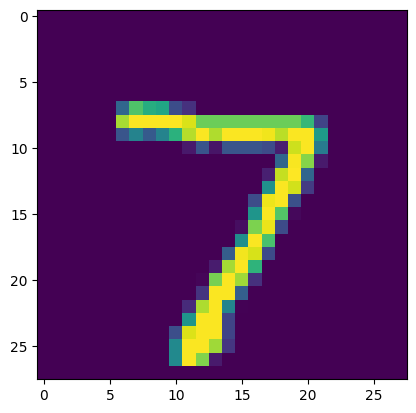

In [12]:
pred = model.predict(x_test[0:1])
print(pred.argmax())
plt.imshow(x_test[0].reshape(28,28))
plt.show()

lưu model

In [11]:
model.save("cnn_model.h5")

# Load lại
model = tf.keras.models.load_model("cnn_model.h5")